First 5 rows:
                 time  G(i)  H_sun   T2m  WS10m  Int
0 2015-01-01 00:11:00   0.0    0.0  1.59   2.83  0.0
1 2015-01-01 01:11:00   0.0    0.0  1.14   2.76  0.0
2 2015-01-01 02:11:00   0.0    0.0  0.69   2.83  0.0
3 2015-01-01 03:11:00   0.0    0.0  0.31   2.97  0.0
4 2015-01-01 04:11:00   0.0    0.0 -0.06   3.10  0.0

Column data types:
time     datetime64[us]
G(i)            float64
H_sun           float64
T2m             float64
WS10m           float64
Int             float64
dtype: object

Time range: 2015-01-01 00:11:00 to 2023-12-31 23:11:00


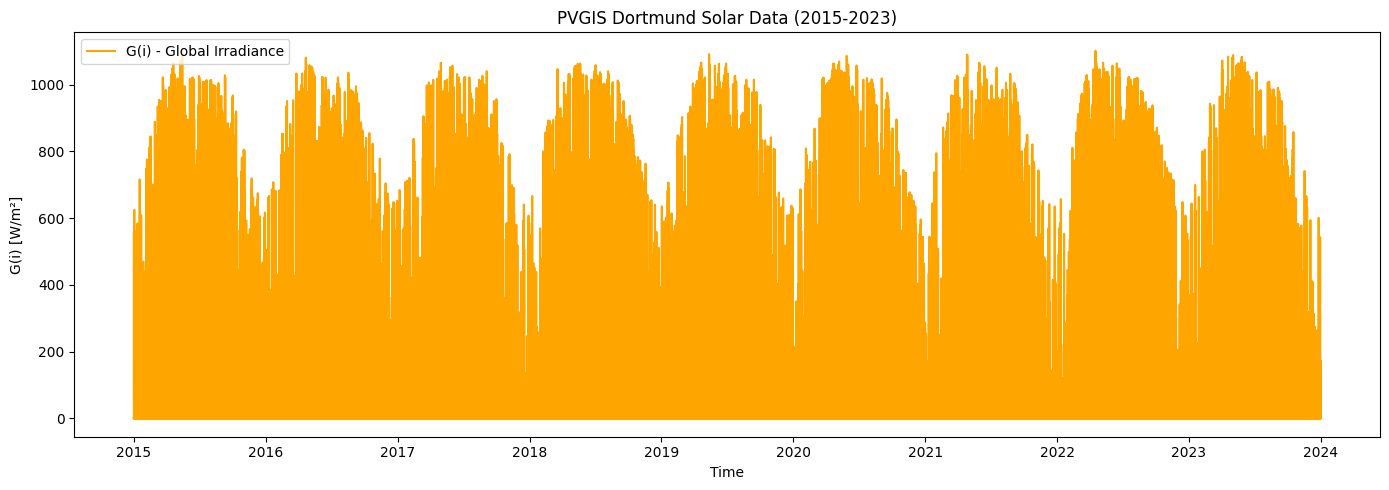

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Read CSV, skip metadata
data = pd.read_csv(
    r"S:/Studies and Docs/Energy Portfolio/pv_performance_analysis/data/dortmund_solar_data_2015-23.csv",
    skiprows=8  # Skip metadata lines
)

# Step 2: Strip whitespace from column names
data.columns = data.columns.str.strip()

# Step 3: Convert 'time' to datetime (PVGIS format: YYYYMMDD:HHMM)
data['time'] = pd.to_datetime(data['time'], format='%Y%m%d:%H%M', errors='coerce')

# Step 4: Convert numeric columns to float
numeric_cols = ['G(i)', 'H_sun', 'T2m', 'WS10m', 'Int']
data[numeric_cols] = data[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Step 5: Inspect the data
print("First 5 rows:")
print(data.head())
print("\nColumn data types:")
print(data.dtypes)
print("\nTime range:", data['time'].min(), "to", data['time'].max())

# Step 6: Plot Global Irradiance over time
plt.figure(figsize=(14,5))
plt.plot(data['time'], data['G(i)'], color='orange', label='G(i) - Global Irradiance')
plt.xlabel("Time")
plt.ylabel("G(i) [W/m²]")
plt.title("PVGIS Dortmund Solar Data (2015-2023)")
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
import seaborn as sns
import plotly


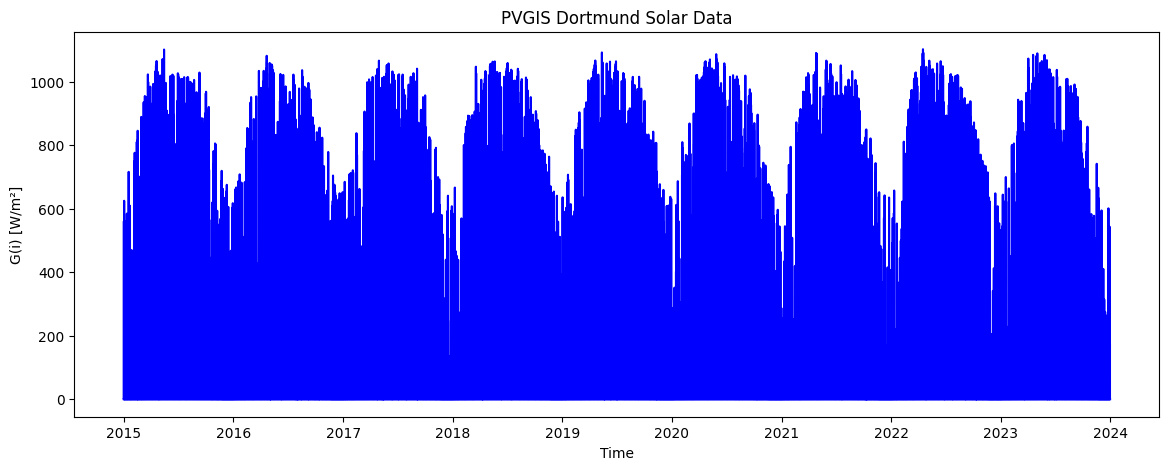

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv("S:/Studies and Docs/Energy Portfolio/pv_performance_analysis/data/dortmund_solar_data_2015-23.csv", skiprows=8)
data.columns = data.columns.str.strip()
data['time'] = pd.to_datetime(data['time'], format='%Y%m%d:%H%M',
errors='coerce')
numeric_cols = ['G(i)','H_sun','T2m','WS10m','Int']
data[numeric_cols] = data[numeric_cols].apply(pd.to_numeric, errors='coerce')
plt.figure(figsize=(14,5))
plt.plot(data['time'], data['G(i)'], color='blue')
plt.xlabel("Time")
plt.ylabel("G(i) [W/m²]")
plt.title("PVGIS Dortmund Solar Data")
plt.show()

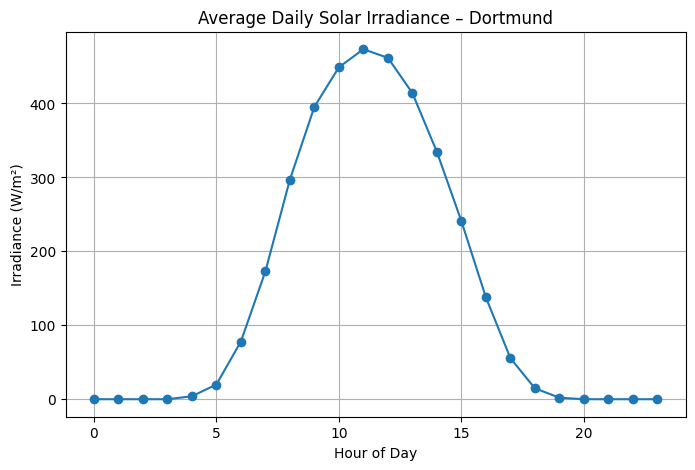

In [4]:
# Extract hour from timestamp
data['hour'] = data['time'].dt.hour

# Average irradiance by hour
hourly_avg = data.groupby('hour')['G(i)'].mean()

plt.figure(figsize=(8,5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')

plt.title("Average Daily Solar Irradiance – Dortmund")
plt.xlabel("Hour of Day")
plt.ylabel("Irradiance (W/m²)")
plt.grid(True)

plt.savefig("../results/average_daily_curve.png")

plt.show()

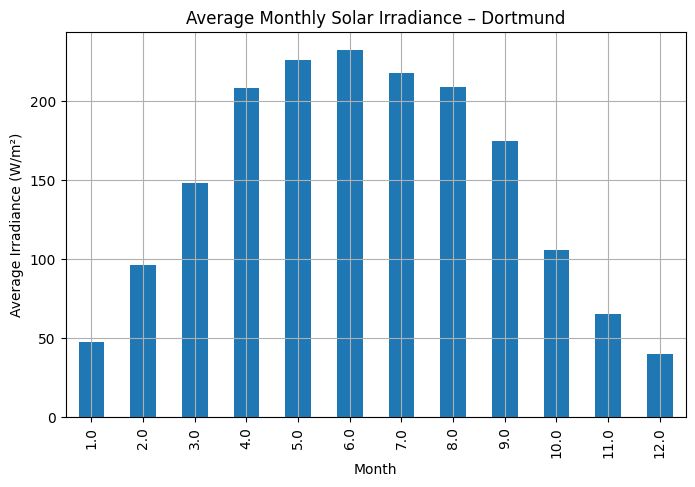

In [5]:
data['month'] = data['time'].dt.month

monthly_avg = data.groupby('month')['G(i)'].mean()

plt.figure(figsize=(8,5))

monthly_avg.plot(kind='bar')

plt.title("Average Monthly Solar Irradiance – Dortmund")
plt.xlabel("Month")
plt.ylabel("Average Irradiance (W/m²)")

plt.grid(True)

plt.savefig("../results/monthly_irradiance.png")

plt.show()

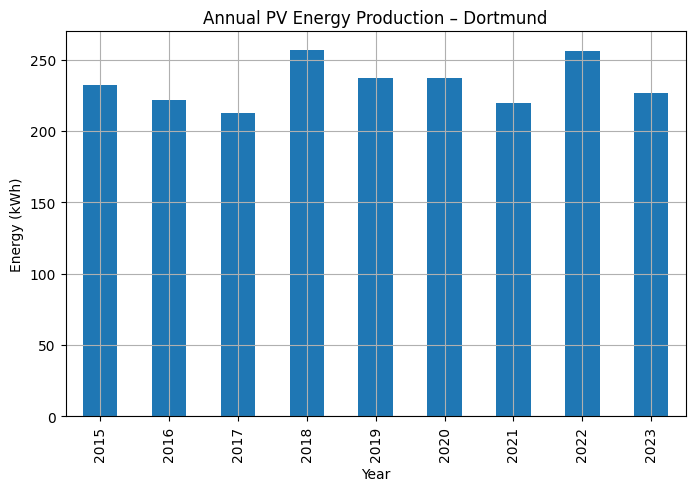

In [6]:
# PV assumptions
area = 1                     #panel area
efficiency = 0.18            #panel efficiency

# Calculate PV energy
data['PV_energy_Wh'] = data['G(i)'] * area * efficiency

# Annual energy
annual_energy = data.resample('YE', on='time')['PV_energy_Wh'].sum() / 1000

# Convert index to year (this fixes the plotting issue)
annual_energy.index = annual_energy.index.year

# Plot
plt.figure(figsize=(8,5))
annual_energy.plot(kind='bar')

plt.title("Annual PV Energy Production – Dortmund")
plt.xlabel("Year")
plt.ylabel("Energy (kWh)")
plt.grid(True)

plt.show()

In [7]:
# Adding calculated energy to data(csv file)
data.to_csv("dortmund_solar_data_2015-23_with_energy.csv", index=False)

In [8]:
# Showing location to store the new data
data.to_csv(r"S:/Studies and Docs/Energy Portfolio/pv_performance_analysis/data/dortmund_solar_data_2015-23_with_energy.csv", index=False)

In [9]:
data.rename(columns={
    'G(i)': 'Global_Irradiance_W_per_m2',
    'H_sun': 'Sun_Hours',
    'T2m': 'Temperature_2m_C',
    'WS10m': 'WindSpeed_10m_m_s',
    'Int': 'Irradiance_Index',
    'PV_energy_Wh': 'PV_Energy_Wh'
}, inplace=True)

In [10]:
print(data.columns.tolist())

['time', 'Global_Irradiance_W_per_m2', 'Sun_Hours', 'Temperature_2m_C', 'WindSpeed_10m_m_s', 'Irradiance_Index', 'hour', 'month', 'PV_Energy_Wh']


In [11]:
data.columns = data.columns.str.strip()

In [12]:
# Saving the DataFrame with new names
data.to_csv(
    r"S:/Studies and Docs/Energy Portfolio/pv_performance_analysis/data/dortmund_solar_data_2015-23_with_energy.csv",
    index=False
)

In [13]:
# Pretty formatting

data.to_csv(
    r"S:/Studies and Docs/Energy Portfolio/pv_performance_analysis/data/dortmund_solar_data_2015-23_pretty.csv",
    index=False,
    float_format='%.1f'  # rounds all floats to 1 decimal
)

In [14]:
# Save as a “pretty” Excel file instead of csv
import pandas as pd

# Save DataFrame to Excel
data.to_excel(
    r"S:/Studies and Docs/Energy Portfolio/pv_performance_analysis/data/dortmund_solar_data_2015-23_pretty.xlsx",
    index=False
)


In [15]:
# Round numeric values for clarity

data['PV_Energy_Wh'] = data['PV_Energy_Wh'].round(1)
data['Temperature_2m_C'] = data['Temperature_2m_C'].round(1)
data['Global_Irradiance_W_per_m2'] = data['Global_Irradiance_W_per_m2'].round(0)

In [16]:
# saved the pretty data to data folder
data.to_csv(r"S:/Studies and Docs/Energy Portfolio/pv_performance_analysis/data/pretty_data.csv", index=False, float_format='%.1f', sep='|')

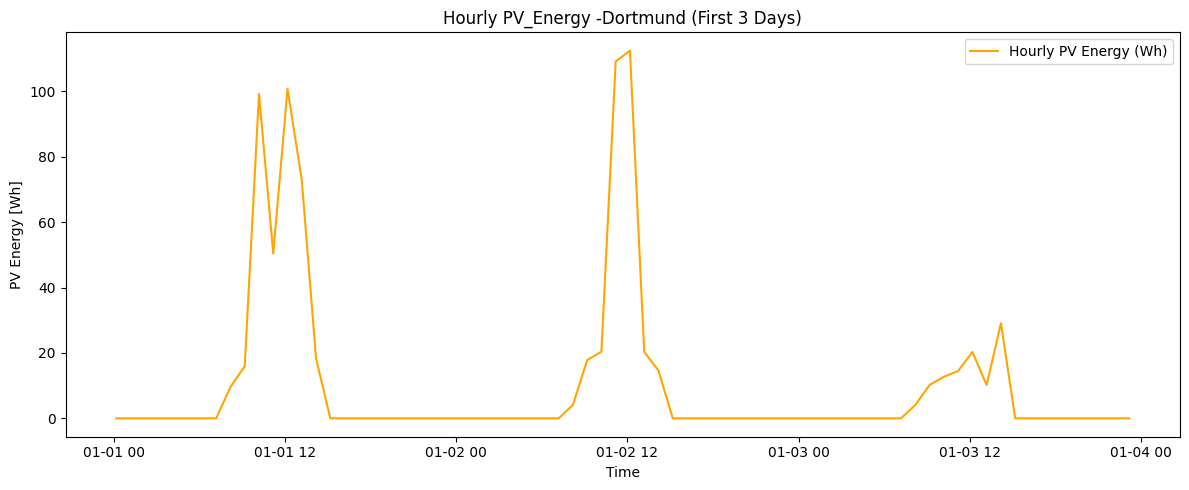

In [17]:
import matplotlib.pyplot as plt

# Plot hourly PV energy for first 3 days
subset = data[data['time'] < '2015-01-04']
plt.figure(figsize=(12,5))
plt.plot(subset['time'], subset['PV_Energy_Wh'], color='orange', label='Hourly PV Energy (Wh)')
plt.xlabel("Time")
plt.ylabel("PV Energy [Wh]")
plt.title("Hourly PV_Energy -Dortmund (First 3 Days)")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(
    r"S:/Studies and Docs/Energy Portfolio/pv_performance_analysis/data/dortmund_solar_data_2015-23_pretty.csv"
)

# convert time column again
data['time'] = pd.to_datetime(data['time'])

print(data.head())

                 time  Global_Irradiance_W_per_m2  Sun_Hours  \
0 2015-01-01 00:11:00                         0.0        0.0   
1 2015-01-01 01:11:00                         0.0        0.0   
2 2015-01-01 02:11:00                         0.0        0.0   
3 2015-01-01 03:11:00                         0.0        0.0   
4 2015-01-01 04:11:00                         0.0        0.0   

   Temperature_2m_C  WindSpeed_10m_m_s  Irradiance_Index  hour  month  \
0               1.6                2.8               0.0   0.0    1.0   
1               1.1                2.8               0.0   1.0    1.0   
2               0.7                2.8               0.0   2.0    1.0   
3               0.3                3.0               0.0   3.0    1.0   
4              -0.1                3.1               0.0   4.0    1.0   

   PV_Energy_Wh  
0           0.0  
1           0.0  
2           0.0  
3           0.0  
4           0.0  


In [19]:
# Set time as index, this makes time aggregation easier.
data.set_index('time', inplace=True)

In [20]:
#Calculate DAILY PV Energy, We now sum all hourly energy values in a day.
daily_energy = data['PV_Energy_Wh'].resample('D').sum() / 1000

In [21]:
print(daily_energy.head())

time
2015-01-01    0.3670
2015-01-02    0.2987
2015-01-03    0.1011
2015-01-04    0.4709
2015-01-05    0.3417
Name: PV_Energy_Wh, dtype: float64


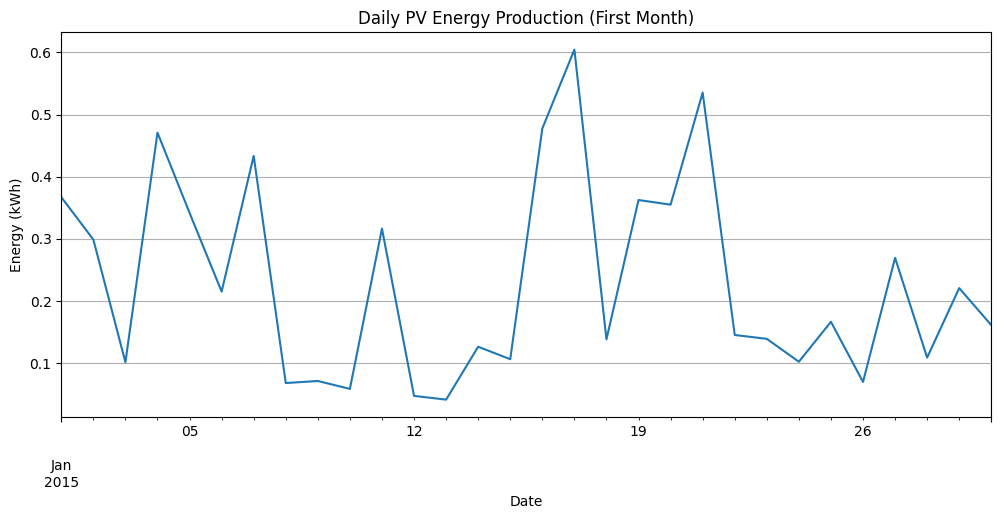

In [ ]:
#Plot Daily PV Energy, Plot first 30 days so it’s readable.

plt.figure(figsize=(12,5))

daily_energy.iloc[:30].plot()

plt.title("Daily PV Energy Production (First Month)")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.grid(True)

plt.show()

In [23]:
#Calculate MONTHLY PV Energy, Now group the daily values into monthly totals.
monthly_energy = daily_energy.resample('ME').sum()

In [24]:
print(monthly_energy.head())

time
2015-01-31     7.1230
2015-02-28    11.9617
2015-03-31    19.8191
2015-04-30    28.3147
2015-05-31    26.8562
Freq: ME, Name: PV_Energy_Wh, dtype: float64


In [28]:
monthly_avg = monthly_energy.groupby(monthly_energy.index.month).mean()

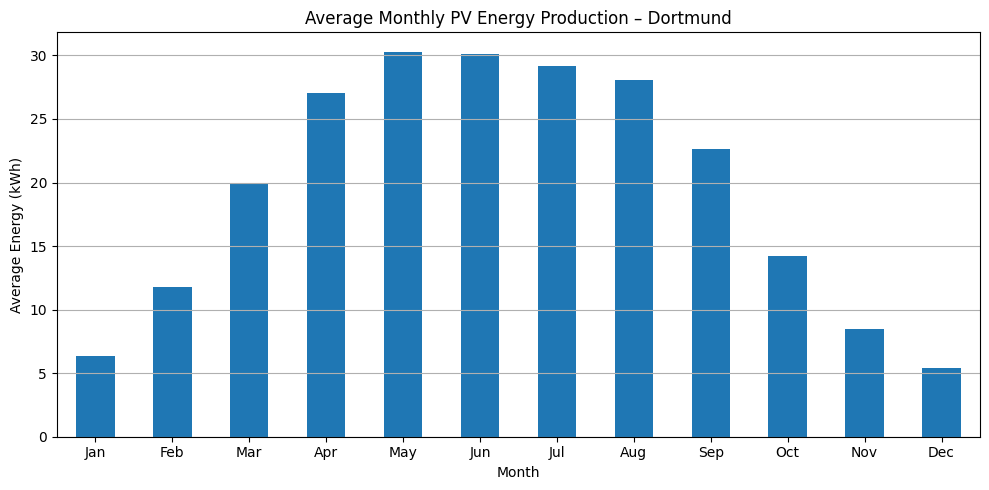

In [29]:
#This monthly plot is NOT for a specific year, it represents the average monthly PV energy across all years (2015–2023),Jan energy = (Jan 2015 + Jan 2016 + ... + Jan 2023) / 9

plt.figure(figsize=(10,5))

monthly_avg.plot(kind='bar')

plt.title("Average Monthly PV Energy Production – Dortmund")
plt.xlabel("Month")
plt.ylabel("Average Energy (kWh)")
plt.xticks(
    range(12),
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    rotation=0
)

plt.grid(axis='y')

plt.tight_layout()
plt.show()

In [31]:
daily_energy.to_csv(
r"S:/Studies and Docs/Energy Portfolio/pv_performance_analysis/results/daily_energy.csv"
)

In [32]:
monthly_energy.to_csv(
r"S:/Studies and Docs/Energy Portfolio/pv_performance_analysis/results/monthly_energy.csv"
)